<a href="https://colab.research.google.com/github/Kushwanth2310/Machine-Learning/blob/main/K_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#core knn

import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    # Euclidean distance
    def _distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    # Predict one sample
    def _predict(self, x):
        distances = []

        for i in range(len(self.X_train)):
            dist = self._distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))

        # sort by distance
        distances.sort(key=lambda x: x[0])

        # get k nearest labels
        k_nearest_labels = [label for _, label in distances[:self.k]]

        # majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    # Predict multiple samples
    def predict(self, X):
        return np.array([self._predict(x) for x in X])

In [31]:
#sqrt(n) rule to define k
def sqrt_k_rule(n):
    return int(np.sqrt(n))

In [35]:
# cross validation
from sklearn.model_selection import train_test_split, KFold
from sklearn import datasets

# Load dataset
data = datasets.load_iris()
X = data.data
y = data.target

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Cross-validation
def cross_validate_knn(X, y, k_values, folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    avg_accuracies = []

    for k in k_values:
        accuracies = []

        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            model = KNN(k=k)
            model.fit(X_tr, y_tr)

            predictions = model.predict(X_val)
            acc = np.mean(predictions == y_val)
            accuracies.append(acc)

        avg_accuracies.append(np.mean(accuracies))

    return avg_accuracies

In [36]:
# K from sqrt rule
k_sqrt = sqrt_k_rule(len(X_train))
print("K from sqrt rule:", k_sqrt)

# Try multiple K values
k_values = list(range(1, 31))
accuracies = cross_validate_knn(X_train, y_train, k_values)

# Best K from cross-validation
best_k = k_values[np.argmax(accuracies)]
print("Best K from CV:", best_k)

K from sqrt rule: 10
Best K from CV: 11


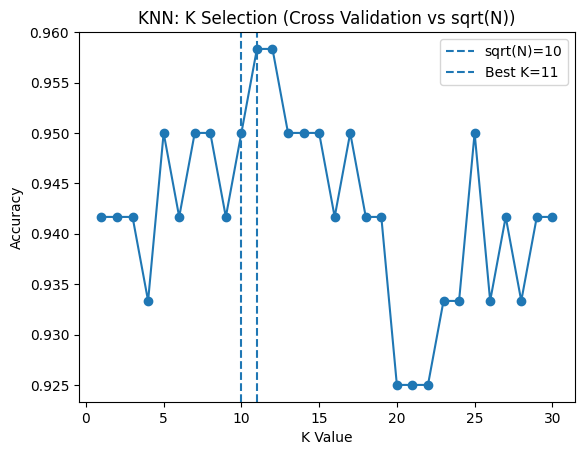

In [34]:
#plotting
import matplotlib.pyplot as plt

plt.plot(k_values, accuracies, marker='o')
plt.axvline(x=k_sqrt, linestyle='--', label=f'sqrt(N)={k_sqrt}')
plt.axvline(x=best_k, linestyle='--', label=f'Best K={best_k}')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN: K Selection (Cross Validation vs sqrt(N))")
plt.legend()

plt.show()